In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from sklearn.model_selection import train_test_split

import torch

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️ Device: cpu


In [2]:
# ==================== CONFIGURATION ====================

# Taille originale des images du dataset
ORIGINAL_SIZE = 299

# Hyperparamètres d'entraînement
IMG_SIZE = 64              # Taille d'entrée

# Preprocessing (conclusions notebook 02)
APPLY_CLAHE = True          # CLAHE améliore le contraste
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# Seuils outliers (ajustés notebook 02)
OUTLIER_LOW = 65
OUTLIER_HIGH = 190

# Catégories à utiliser (toutes pour la segmentation)
CATEGORIES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

print("✅ Configuration chargée")
print(f"   - Taille originale: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"   - Taille réseau: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - CLAHE: {APPLY_CLAHE}")

✅ Configuration chargée
   - Taille originale: 299x299
   - Taille réseau: 64x64
   - CLAHE: True


In [3]:
import kagglehub

# Téléchargement du dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
base_path = Path(path)
data_path = base_path / "COVID-19_Radiography_Dataset"

print(f"✅ Dataset téléchargé: {base_path}")
print(f"📁 Data path: {data_path}")

100%|██████████| 778M/778M [00:06<00:00, 121MB/s]

Extracting files...


✅ Dataset téléchargé: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5
📁 Data path: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset


In [4]:
# Initialize an empty dictionary to store image paths
image_paths = {}

# Construct paths for 'images' and 'masks' for each category
for category in CATEGORIES:
    # Path for images
    image_dir = os.path.join(data_path, category, 'images')
    image_paths[f'{category}_images'] = image_dir

    # Path for masks
    mask_dir = os.path.join(data_path, category, 'masks')
    image_paths[f'{category}_masks'] = mask_dir

# Print the image_paths dictionary to verify
print("Image Paths Dictionary:")
for key, value in image_paths.items():
    print(f"{key}: {value}")

Image Paths Dictionary:
COVID_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/COVID/images
COVID_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/COVID/masks
Normal_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/images
Normal_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/masks
Lung_Opacity_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Lung_Opacity/images
Lung_Opacity_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Lung_Opacity/masks
Viral Pneumonia_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-d


Displaying samples for category: COVID


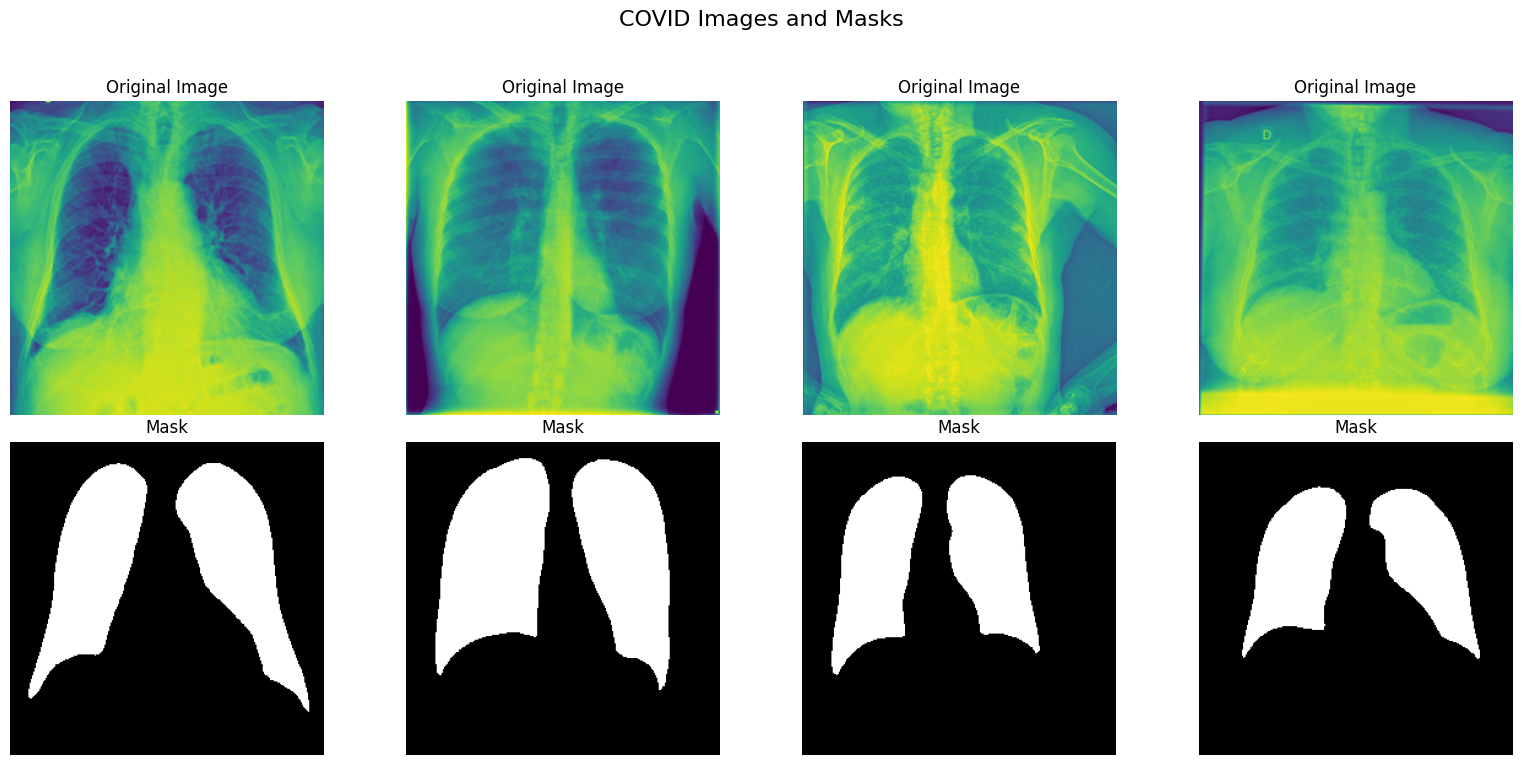


Displaying samples for category: Normal


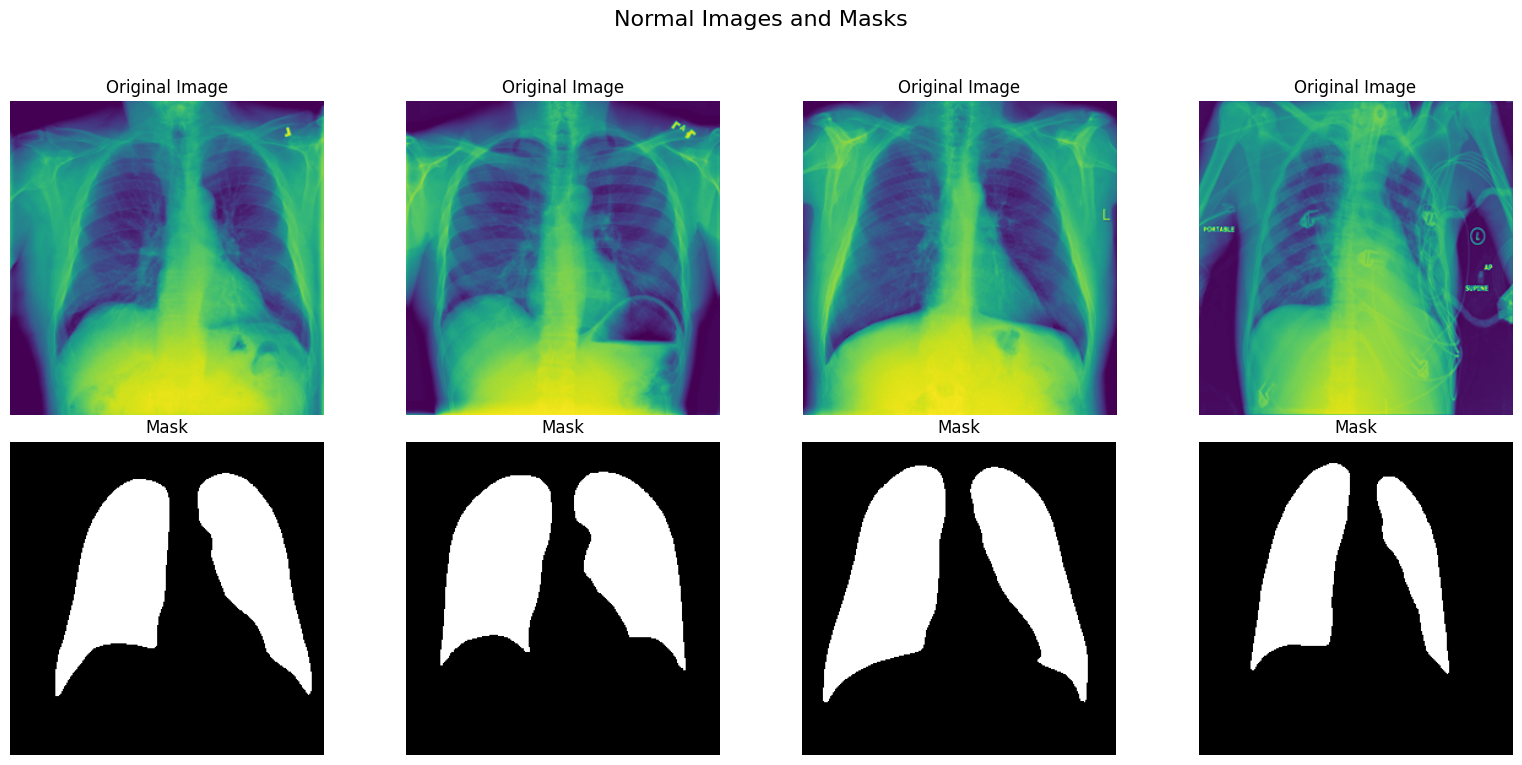


Displaying samples for category: Lung_Opacity


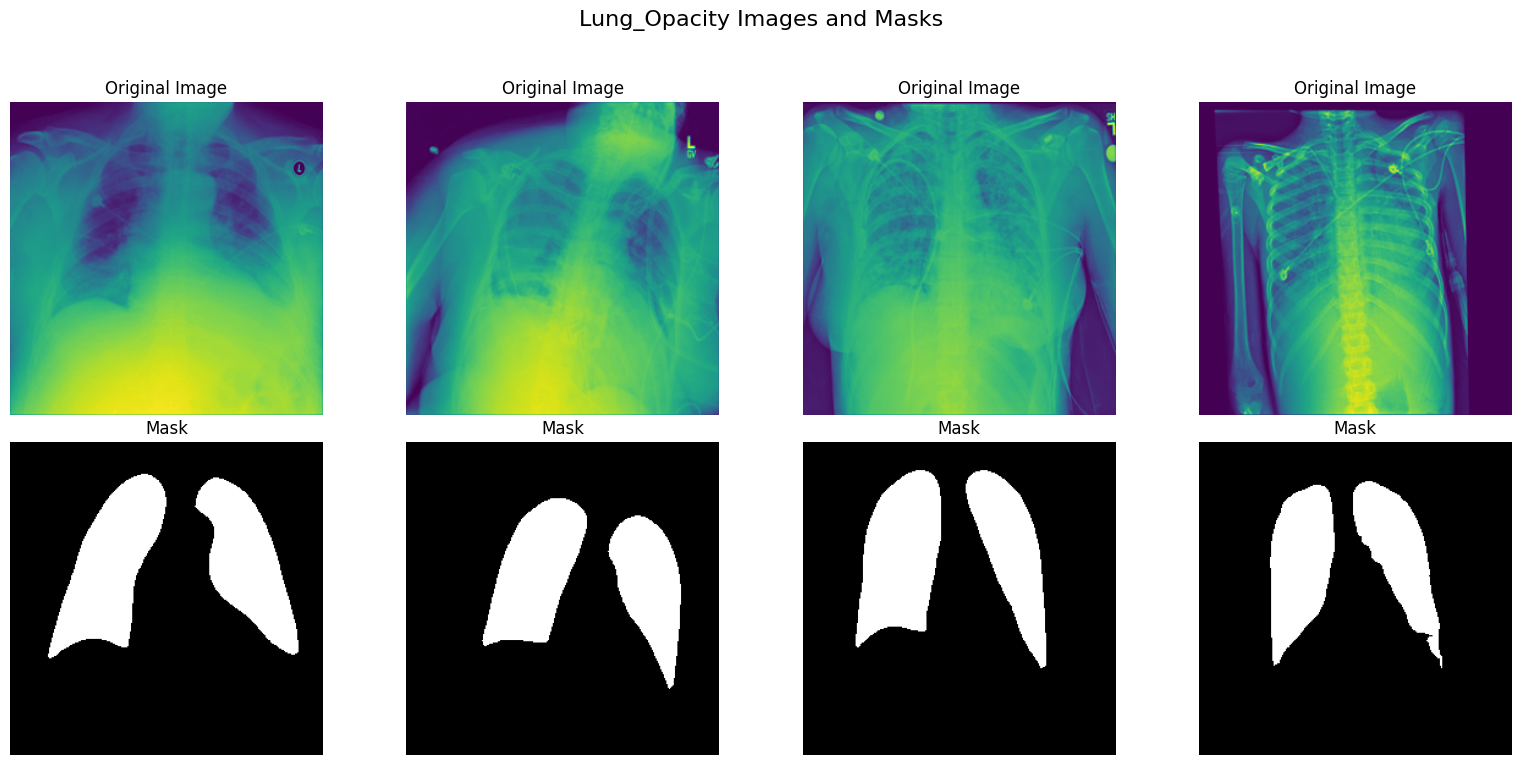


Displaying samples for category: Viral Pneumonia


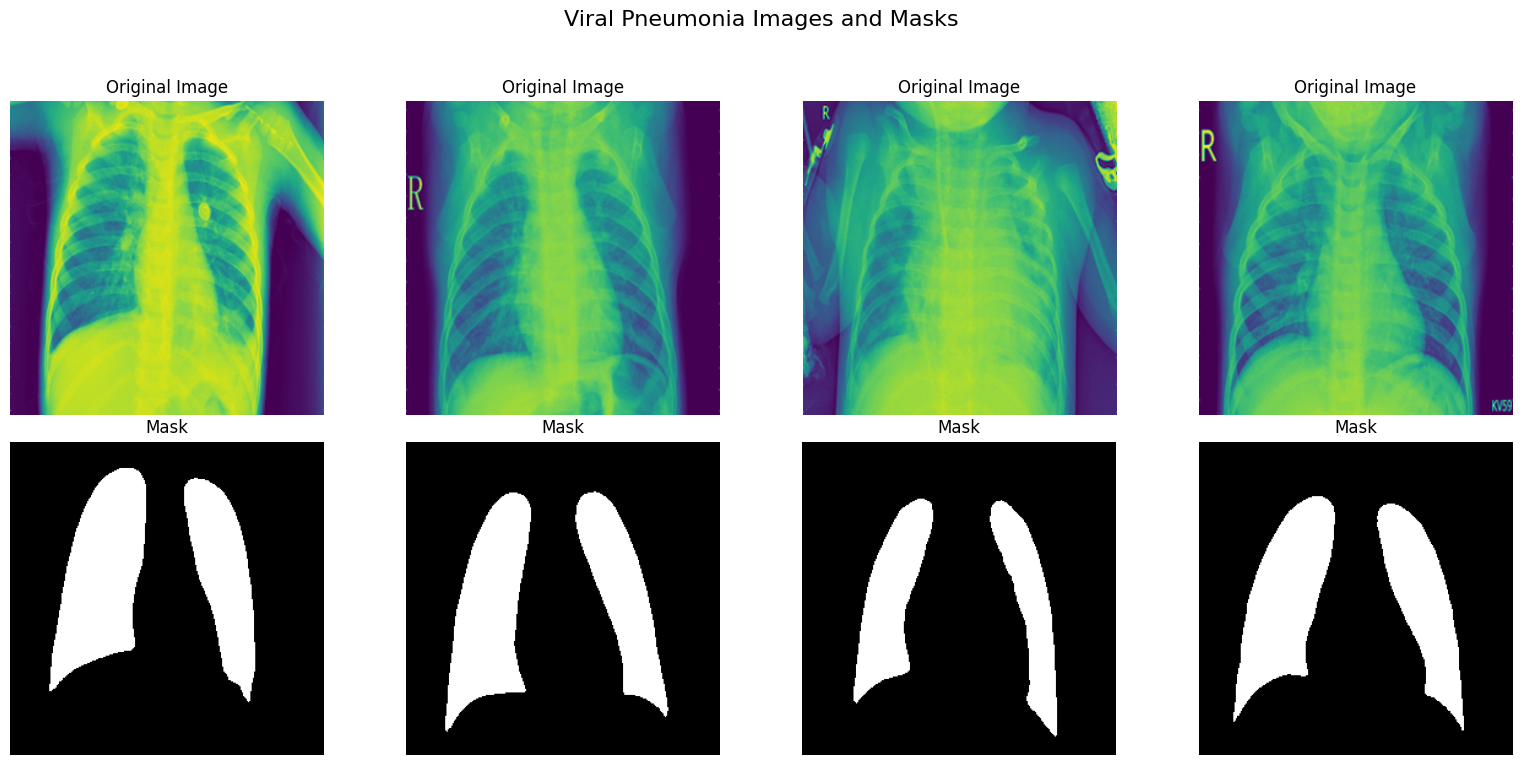

In [5]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# On suppose que 'CATEGORIES' et 'image_paths' ont déjà été définis aux étapes précédentes
# CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
# image_paths = { ... dictionnaire rempli ... }

# Boucle sur chaque catégorie pour afficher des exemples d'images et de masques
for category in CATEGORIES:
    print(f"\nDisplaying samples for category: {category}")

    # Récupérer les répertoires des images et des masques pour la catégorie courante
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Obtenir la liste de tous les fichiers image dans la catégorie courante
    all_image_files = [
        f for f in os.listdir(current_image_dir)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Sélectionner aléatoirement 4 fichiers image
    # S'assurer de ne pas sélectionner plus de fichiers qu'il n'en existe
    num_samples = min(4, len(all_image_files))
    selected_image_files = random.sample(all_image_files, num_samples)

    # Créer une figure avec une grille 2 x num_samples de sous-graphiques
    fig = plt.figure(figsize=(4 * num_samples, 8))
    fig.suptitle(f'{category} Images and Masks', fontsize=16)

    # # Si aucune image n'est trouvée pour cette catégorie, on peut ignorer l'affichage
    # if num_samples == 0:
    #     print(f"Aucune image trouvée pour la catégorie {category}.")
    #     plt.close(fig)
    #     continue

    for i, img_filename in enumerate(selected_image_files):
        # Construire les chemins complets pour l'image et le masque
        image_path = os.path.join(current_image_dir, img_filename)
        mask_path = os.path.join(current_mask_dir, img_filename)  # On suppose que le masque porte le même nom de fichier

        # Charger l'image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Charger le masque (s'il existe)
        mask = None
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            print(f"Warning: Mask not found for {img_filename} in {category}.")

        # Afficher l'image originale sur la première ligne
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        # Afficher le masque sur la deuxième ligne
        plt.subplot(2, num_samples, num_samples + i + 1)
        if mask is not None:
            # Les masques sont généralement en niveaux de gris
            plt.imshow(mask, cmap='gray')
            plt.title('Mask')
        else:
            # Afficher un texte si le masque est indisponible
            plt.text(
                0.5, 0.5, 'Mask N/A',
                horizontalalignment='center',
                verticalalignment='center',
                transform=plt.transAxes,
                fontsize=12,
                color='red'
            )
        plt.axis('off')

    # Ajuster la mise en page pour laisser de la place au titre principal
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Prétraitement des images et préparation des données
Prétraitez les images radiographiques en chargeant les images et leurs masques en niveaux de gris, en appliquant les masques pour isoler la région d'intérêt, en redimensionnant chaque image masquée à 64x64 pixels, puis en appliquant l'amélioration du contraste CLAHE. Aplatissez chaque image traitée en un vecteur de caractéristiques 1D et associez-le à son étiquette de catégorie. Standardisez ces vecteurs de caractéristiques avec `StandardScaler` et divisez l'ensemble de données en ensembles d'entraînement et de test. Entraînez un modèle `SVC` de scikit-learn sur les données d'entraînement. Évaluez les performances du modèle en générant et en affichant un `classification_report` ainsi qu'une `confusion_matrix` visualisée, et interprétez les résultats pour évaluer la classification des images radiographiques. Expliquez que la régression logistique de scikit-learn est une tâche CPU et que l'utilisation directe du GPU n'est pas applicable.

Charger toutes les images et leurs masques en niveaux de gris, appliquer les masques pour isoler la région d'intérêt, redimensionner les images masquées à 64x64 pixels, appliquer l'amélioration du contraste CLAHE, puis aplatir chaque image traitée en un vecteur de caractéristiques 1D et l'associer à l'étiquette de catégorie.


In [ ]:
# =======================================================================================================================
# La première étape consiste à initialiser les listes destinées aux "features" et aux "labels", puis à créer l’objet CLAHE. 
# Cela permet de préparer les composants nécessaires avant de parcourir les images pour effectuer leur prétraitement. 
# =======================================================================================================================

features_list = []
labels_list = []

# Créer l'objet CLAHE
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_SIZE)

print("✅ Listes initialisées et objet CLAHE créé.")

✅ Listes initialisées et objet CLAHE créé.


In [ ]:
#======================================================================================================================================
#  cette étape consiste à parcourir chaque catégorie, 
# à charger les images et les masques, 
# à appliquer le masquage, 
# à redimensionner les images, 
# à appliquer CLAHE si APPLY_CLAHE vaut True, 
# puis à aplatir chaque image. 
# 
# Le vecteur de features obtenu ainsi que le label correspondant sont ensuite ajoutés aux listes initialisées précédemment.
#======================================================================================================================================

for category in CATEGORIES:
    # Accéder aux répertoires des images et des masques pour la catégorie actuelle
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Parcourir tous les fichiers image
    print(f"Processing {category}...")
    for img_filename in os.listdir(current_image_dir):
        if img_filename.endswith(('.png', '.jpg', '.jpeg')):
            # Construire les chemins complets pour l'image et le masque
            image_path = os.path.join(current_image_dir, img_filename)
            mask_path = os.path.join(current_mask_dir, img_filename)

            # Charger l'image en niveaux de gris
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            # Charger le masque en niveaux de gris
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is not None and mask is not None:
                # Ensure mask has the same size as the image
                if img.shape != mask.shape:
                    # Resize mask to match image dimensions. INTER_NEAREST is often preferred for masks.
                    mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

                # Appliquer le masque à l'image
                # Ensure mask is binary (0 or 255) for bitwise_and to work as expected
                _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
                masked_img = cv2.bitwise_and(img, img, mask=binary_mask)

                # Redimensionner l'image masquée
                resized_img = cv2.resize(masked_img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

                # Appliquer CLAHE si activé
                if APPLY_CLAHE:
                    processed_img = clahe.apply(resized_img)
                else:
                    processed_img = resized_img

                # Aplatir l'image en un vecteur 1D
                features_list.append(processed_img.flatten())
                # Ajouter l'étiquette de catégorie
                labels_list.append(category)
            else:
                print(f"Warning: Could not load image or mask for {img_filename} in {category}. Skipping.")

print("✅ Toutes les images ont été traitées.")
print(f"Nombre total de caractéristiques extraites: {len(features_list)}")
print(f"Nombre total d'étiquettes: {len(labels_list)}")

Processing COVID...
Processing Normal...
Processing Lung_Opacity...
Processing Viral Pneumonia...
✅ Toutes les images ont été traitées.
Nombre total de caractéristiques extraites: 21165
Nombre total d'étiquettes: 21165


In [ ]:
#=======================================================================================================================
# L’étape précédente a permis de prétraiter correctement les images et d’extraire les caractéristiques dans des listes.
# Cette étape consiste à convertir ces listes en tableaux NumPy afin de faciliter le traitement 
# et d’assurer leur compatibilité avec scikit-learn. 
# Il faut ensuite encoder les étiquettes catégorielles, initialement sous forme de chaînes de caractères, en valeurs numériques, 
# car ce format est requis par les modèles de machine learning.
#=======================================================================================================================

from sklearn.preprocessing import LabelEncoder

# Convertir les listes en tableaux NumPy
X = np.array(features_list)
y_str = np.array(labels_list)

# Encoder les étiquettes de catégorie (chaînes de caractères) en valeurs numériques
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)

print(f"✅ Données converties en tableaux NumPy: X.shape={X.shape}, y.shape={y.shape}")
print(f"✅ Étiquettes encodées: {label_encoder.classes_}")


✅ Données converties en tableaux NumPy: X.shape=(21165, 4096), y.shape=(21165,)
✅ Étiquettes encodées: ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Modèle PCA + KNN

Remplacement du SVC par un **KNN** en conservant le meilleur résultat PCA précédent : **200 composantes**.

⏳ Début de l'entraînement du modèle...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'pca__n_components': 200, 'svc__C': 10, 'svc__gamma': 'scale'}
Best CV f1_macro: 0.7281656250058871
✅ Entraînement du modèle terminé en 9459.75 secondes.
✅ Prédictions effectuées sur l'ensemble de test.

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.51      0.57      0.54       723
           1       0.74      0.72      0.73      1203
           2       0.83      0.82      0.83      2038
           3       0.85      0.87      0.86       269

    accuracy                           0.75      4233
   macro avg       0.74      0.74      0.74      4233
weighted avg       0.75      0.75      0.75      4233

                 precision    recall  f1-score   support

          COVID       0.51      0.57      0.54       723
   Lung_Opacity       0.74      0.72      0.73      1203
         Normal       0.83      0.82    

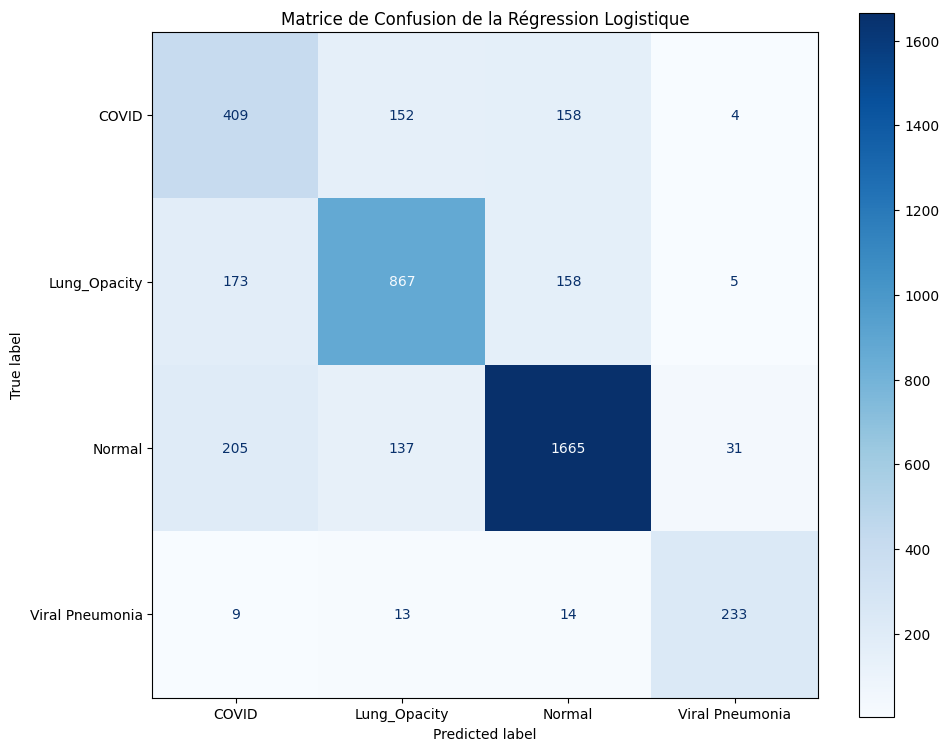

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import time

# Pipeline : Standardisation -> PCA fixé à 200 composantes -> KNN
# Choix KNN :
# - n_neighbors=7 : compromis biais/variance raisonnable
# - weights="distance" : utile quand certaines classes sont plus difficiles à séparer
# - p=2 : distance euclidienne standard dans l'espace PCA
pipe_pca_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=200, random_state=42)),
    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Paramètres utilisés :")
print({
    "pca__n_components": 200,
    "knn__n_neighbors": 7,
    "knn__weights": "distance",
    "knn__metric": "minkowski",
    "knn__p": 2
})

# Validation croisée sur l'ensemble d'entraînement
print("
⏳ Début de la validation croisée (cv=3)...")
cv_scores = cross_val_score(
    pipe_pca_knn,
    X_train,
    y_train,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
print("Scores CV f1_macro:", cv_scores)
print(f"CV f1_macro moyen: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Entraînement final sur tout le train
start_time = time.time()
print("
⏳ Début de l'entraînement final du modèle KNN...")
pipe_pca_knn.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"✅ Entraînement du modèle terminé en {training_time:.2f} secondes.")

best_model = pipe_pca_knn
y_pred = best_model.predict(X_test)

print("✅ Prédictions effectuées sur l'ensemble de test.")

print("
--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

print("
--- Matrice de Confusion ---")
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cmd.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title('Matrice de Confusion du modèle PCA + KNN')
plt.tight_layout()
plt.show()
